In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib
from scipy.integrate import quad

plt.style.use('sty.mplstyle')

# $u_1$ values using the Woods-Saxon Form Factor

In [2]:
AWS = 183.84
sigmaWS = 0.523/0.1973 # GeV^{-1}
rWS = 1.126*AWS**(1/3)/0.1973 # GeV^{-1}

def WS_FF(Q2):
    Q = np.sqrt(Q2)
    main = np.ones_like(Q2)
    cond = Q != 0
    num = np.pi*sigmaWS*np.cosh(np.pi*Q[cond]*sigmaWS)*np.sin(Q[cond]*rWS)/np.sinh(np.pi*Q[cond]*sigmaWS) - rWS*np.cos(Q[cond]*rWS)
    num *= 3*np.pi*sigmaWS
    denom = Q[cond]*rWS*np.sinh(np.pi*Q[cond]*sigmaWS)
    denom *= rWS**2 + np.pi**2*sigmaWS**2
    main[cond] = num/denom
    return main

def WS_FF_squared(Q2):
    return WS_FF(Q2)**2

def u1_WS_FF(Q2):
    main, _ = quad(WS_FF_squared, Q2, np.inf)
    return main
u1_WS_FF = np.vectorize(u1_WS_FF)

# $u_1$ values using the Helm [1st version] Form Factor

In [4]:
cv1_Helm = 1.23*AWS**(1/3) - 0.6 # fm
r0v1_Helm = 0.52 # fm
sv1_Helm = 0.9 # fm
R0v1_Helm = cv1_Helm**2 + 7*np.pi**2*r0v1_Helm**2/3 - 5*sv1_Helm**2 # fm^2
R0v1_Helm = np.sqrt(R0v1_Helm) # fm
R0v1_Helm = R0v1_Helm/0.1973 # GeV^{-1}
sv1_Helm = sv1_Helm/0.1973 # GeV^{-1}

def j1_aux(x):
    cond = x!=0
    main = 1/3*np.ones_like(x)
    num = np.sin(x[cond]) - x[cond]*np.cos(x[cond])
    denom = x[cond]**3
    main[cond] = num/denom
    return main

def Helm_FFv1(Q2):
    Q2 = np.array([Q2])
    Q = np.sqrt(Q2)
    main = 3*j1_aux(Q*R0v1_Helm)*np.exp(-Q2*sv1_Helm**2/2)
    return main

def Helm_FFv1_squared(Q2):
    return Helm_FFv1(Q2)**2

def u1_Helm_FFv1(Q2):
    main, _ = quad(Helm_FFv1_squared, Q2, np.inf)
    return main

u1_Helm_FFv1 = np.vectorize(u1_Helm_FFv1)

# $u_1$ values using the Helm [2nd version] Form Factor

In [5]:
cv2_Helm = 6.51 # fm
r0v2_Helm = 0.535 # fm
sv2_Helm = 0.9 # fm
R0v2_Helm = cv2_Helm**2 + 7*np.pi**2*r0v2_Helm**2/3 - 5*sv2_Helm**2 # fm^2
R0v2_Helm = np.sqrt(R0v2_Helm) # fm
R0v2_Helm = R0v2_Helm/0.1973 # GeV^{-1}
sv2_Helm = sv2_Helm/0.1973 # GeV^{-1}

def Helm_FFv2(Q2):
    Q2 = np.array([Q2])
    Q = np.sqrt(Q2)
    main = 3*j1_aux(Q*R0v2_Helm)*np.exp(-Q2*sv2_Helm**2/2)
    return main

def Helm_FFv2_squared(Q2):
    return Helm_FFv2(Q2)**2

def u1_Helm_FFv2(Q2):
    main, _ = quad(Helm_FFv2_squared, Q2, np.inf)
    return main

u1_Helm_FFv2 = np.vectorize(u1_Helm_FFv2)

# $u_1$ values using the Klein-Nystrand Form Factor

In [6]:
RA_KN = 1.23*AWS**(1/3) # fm
RA_KN = RA_KN/0.1973 # GeV^{-1}
r0_adKN = 5.3658 # fm
ak_adKN = 0.7 # fm
RA_adKN = np.sqrt( 5*r0_adKN**2/3 - 10*ak_adKN**2 ) # fm
RA_adKN = RA_adKN/0.1973 # GeV^{-1}

def KN_FF(Q2, R=1):
    ak_aux = 0.7/0.1973 # GeV^{-1}
    Q2 = np.array([Q2])
    Q = np.sqrt(Q2)
    num = 3*j1_aux(Q*R)
    denom = 1 + Q2*ak_aux**2
    return num/denom

def KN_FF_squared(Q2):
    return KN_FF(Q2, R=RA_KN)**2

def u1_KN_FF(Q2):
    main, _ = quad(KN_FF_squared, Q2, np.inf)
    return main
u1_KN_FF = np.vectorize(u1_KN_FF)

def adKN_FF_squared(Q2):
    return KN_FF(Q2, R=RA_adKN)**2

def u1_adKN_FF(Q2):
    main, _ = quad(adKN_FF_squared, Q2, np.inf)
    return main
u1_adKN_FF = np.vectorize(u1_adKN_FF)

In [8]:
q2W_Diego = np.loadtxt('../csv/InterpolationList/Tungsten/184W_InterpolationListWS_Diego.txt', delimiter=',', usecols=0)
u1W_Diego = np.loadtxt('../csv/InterpolationList/Tungsten/184W_InterpolationListWS_Diego.txt', delimiter=',', usecols=1)

In [9]:
u1_WS_FF_vals = u1_WS_FF(q2W_Diego)
u1_Helm_FFv1_vals = u1_Helm_FFv1(q2W_Diego)
u1_Helm_FFv2_vals = u1_Helm_FFv2(q2W_Diego)
u1_KN_FF_vals = u1_KN_FF(q2W_Diego)
u1_adKN_FF_vals = u1_adKN_FF(q2W_Diego)

# Plotting Tungsten $u_1$ vals

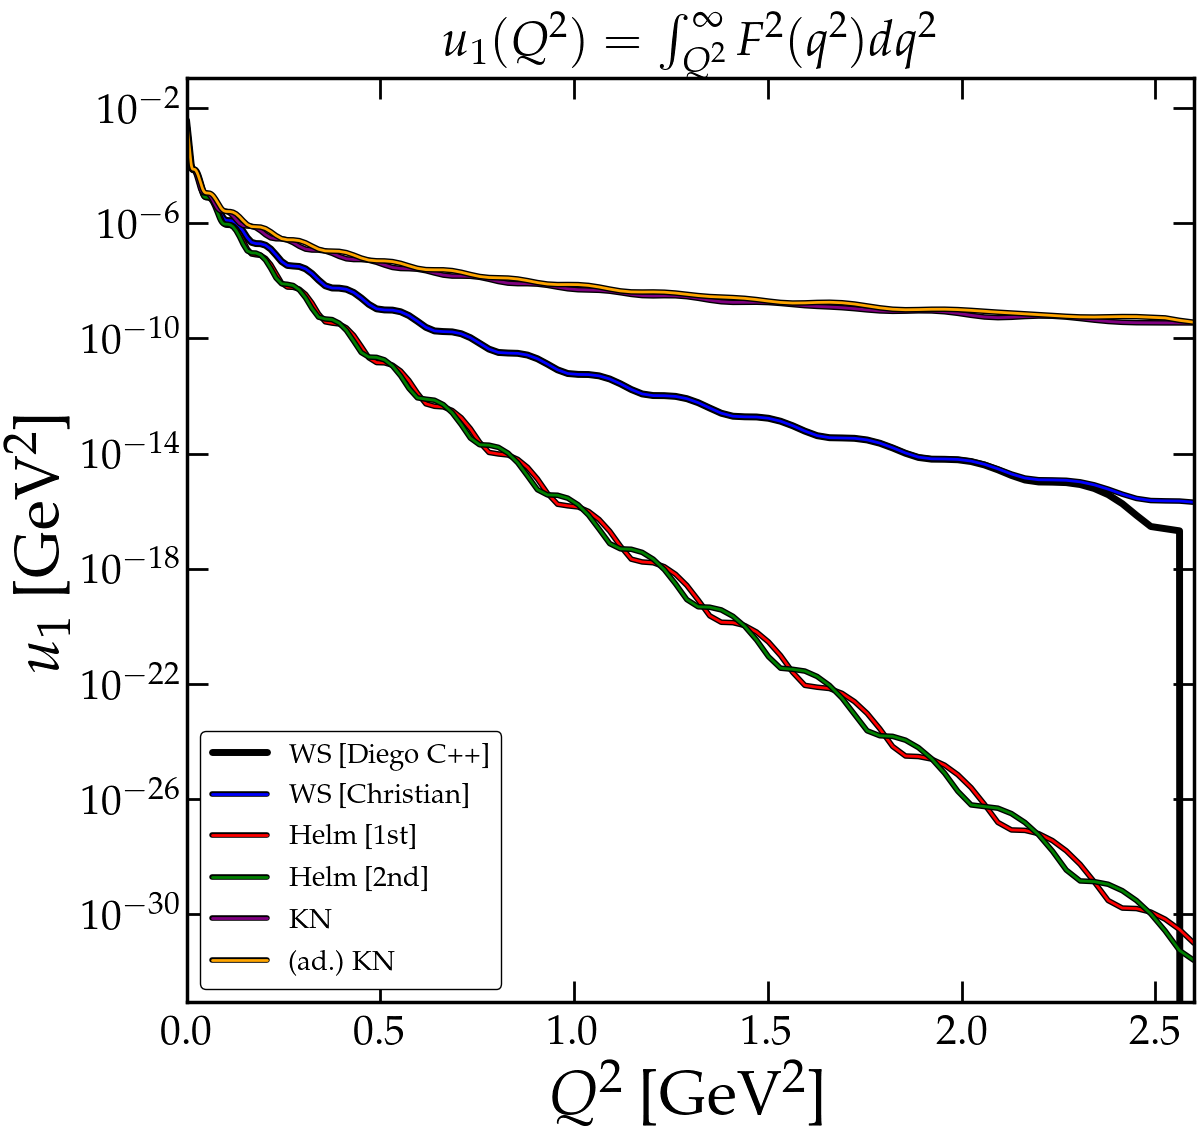

In [10]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(q2W_Diego, u1W_Diego, color='black', lw=5, label='WS [Diego C++]')
ax.plot(q2W_Diego, u1_WS_FF_vals, color='blue', lw=2, label='WS [Christian]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(q2W_Diego, u1_Helm_FFv1_vals, color='red', lw=2, label='Helm [1st]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(q2W_Diego, u1_Helm_FFv2_vals, color='green', lw=2, label='Helm [2nd]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(q2W_Diego, u1_KN_FF_vals, color='purple', lw=2, label='KN', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(q2W_Diego, u1_adKN_FF_vals, color='orange', lw=2, label='(ad.) KN', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])

ax.set_yscale('log')
ax.set_xlim([0, 2.6])

ax.legend(fontsize=20, loc='lower left', frameon=True, framealpha=1, edgecolor='k', fancybox=True)
ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
ax.set_ylabel(r'$u_1$ [GeV$^2$]')
ax.set_title(r'$u_1(Q^2) = \int_{Q^2}^{\infty} F^2 (q^2) dq^2$')

plt.savefig('../Plots/Figures_PDF/Tungsten_u1vals.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/Tungsten_u1vals.png', transparent=False, bbox_inches='tight')